# Geographic Performance Analysis
### Global Electronics Retailer — 8 Countries, 3 Continents

**Author:** _Your Name_
**Dataset:** [Global Electronics Retailer](https://mavenanalytics.io/data-playground/global-electronics-retailer) (Maven Analytics)

This is module 2 of 4 (Sales Performance · **Geographic Performance** · Product Performance · Customer Segmentation). It asks not just "where does revenue come from" but "where is the business genuinely performing well" — which requires normalizing for market size (per-store, per-sqm, per-customer), not just ranking raw totals.


## 1. Research Questions

1. Which markets generate the most revenue and profit — and does that ranking hold once we adjust for store footprint and customer base?
2. Does profitability (margin) vary by geography, or is it a structural, product-driven constant?
3. Which physical stores are the most productive per square meter — and are there stores that appear to generate no sales at all?
4. How does channel mix (Online vs. In-Store) differ by market?
5. Is a store's age related to how well it performs?


## 2. Methodology

We reuse the shared fact table from Module 1 (`src/data_prep.py`) so revenue/profit logic stays identical across every module.

**Geography dimension choice.** The Sales table links to a *store's* country and, through the customer, to the *customer's* country. For Online orders, "store country" is meaningless (`StoreKey = 0`). We therefore report **market-level metrics (revenue, margin, customers, growth) using the customer's country** — this is where the demand actually originates, and it's what the original Power BI dashboards used (verified by reproducing their exact totals). **Store-level operational metrics (revenue per store, per sqm, store age)** necessarily use the **store's own country**, since those are properties of the physical location itself.

**A data-quality check specific to this module:** we cross-referenced every physical StoreKey against the Sales table and found several stores with zero linked transactions across the entire 5-year window — flagged explicitly in Section 4.3 rather than silently excluded.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from data_prep import build_sales_fact_table, load_stores
from viz_style import apply_style, COLORS, PALETTE, add_titles, add_source_note, money_formatter, pct_formatter

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = build_sales_fact_table()
stores = load_stores()
country_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(sorted(df["Country_customer"].dropna().unique()))}
print(f"{df['Country_customer'].nunique()} markets | {(stores['StoreKey']!=0).sum()} physical stores | {df['Continent'].nunique()} continents")

8 markets | 66 physical stores | 3 continents


## 3. Findings

### 3.1 Revenue & Profit by Market

The United States alone generates more than half of all global revenue. But because margin is nearly identical everywhere (see 3.2), profit ranking tracks revenue ranking exactly — no market is disproportionately more or less profitable per dollar of sales.

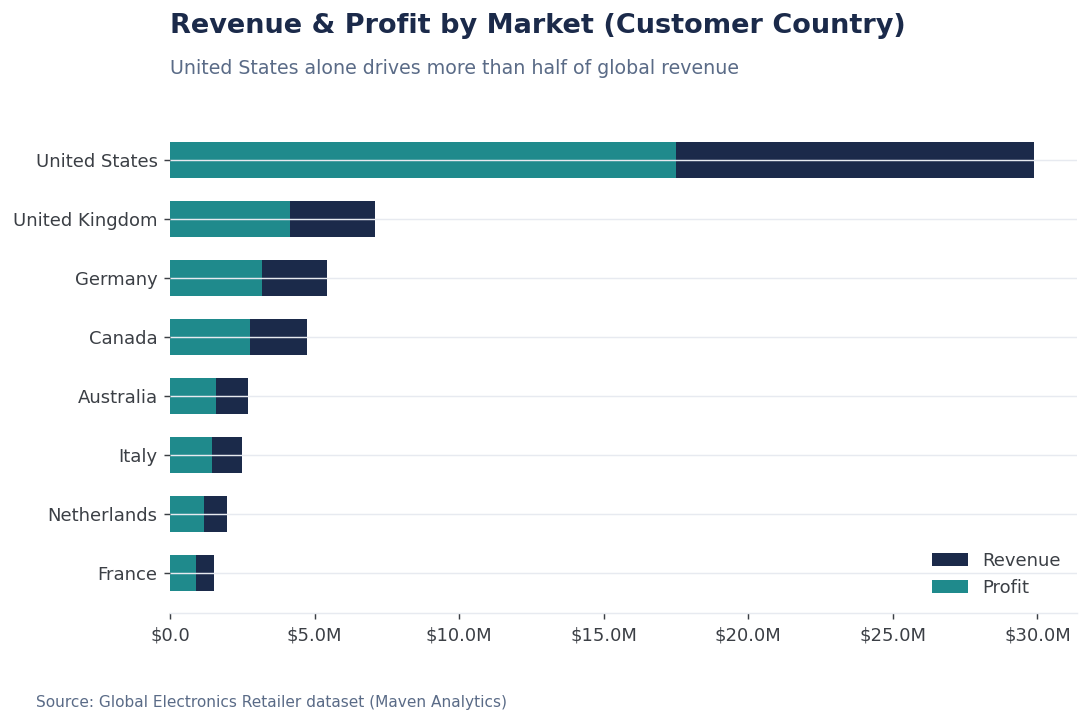

In [2]:
by_country = df.groupby("Country_customer").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum")).sort_values("Revenue", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(by_country))
ax.barh(y, by_country["Revenue"], color=COLORS["primary"], height=0.6, label="Revenue")
ax.barh(y, by_country["Profit"], color=COLORS["positive"], height=0.6, label="Profit")
ax.set_yticks(list(y)); ax.set_yticklabels(by_country.index)
ax.xaxis.set_major_formatter(money_formatter())
add_titles(ax, "Revenue & Profit by Market (Customer Country)", "United States alone drives more than half of global revenue")
ax.legend(loc="lower right")
add_source_note(fig)
plt.savefig("../reports/figures/g01_revenue_profit_by_country.png")
plt.show()

### 3.2 Margin Is a Product Constant, Not a Geography Effect

Every market sits within one percentage point of the global 58.6% margin. This confirms margin is driven by the product cost structure (set centrally), not by local pricing power, competition, or cost-of-doing-business differences.

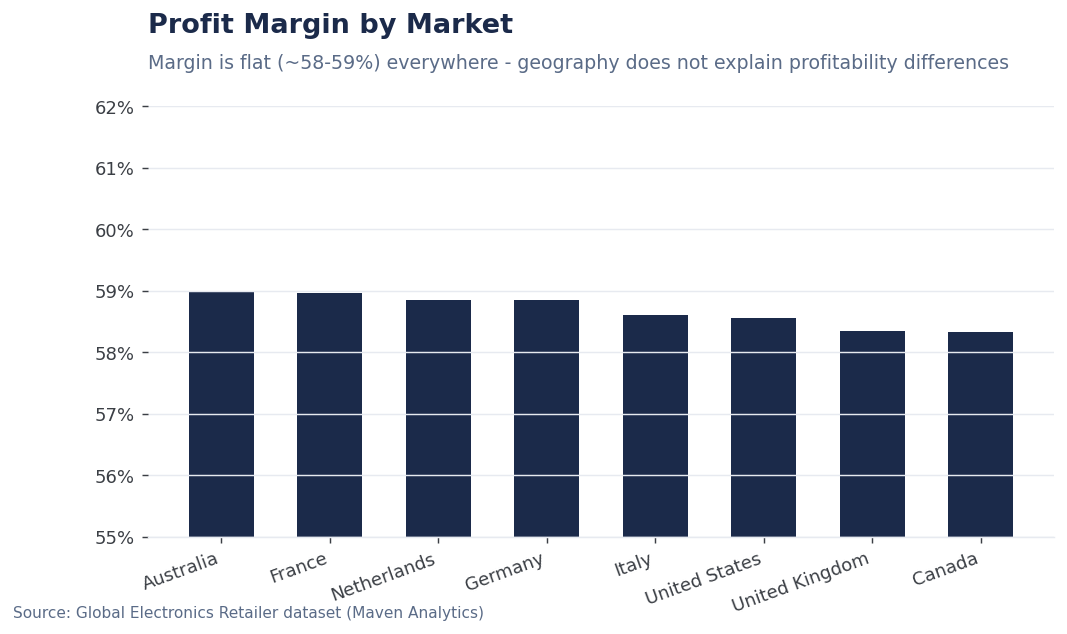

In [3]:
by_country2 = df.groupby("Country_customer").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum"))
by_country2["Margin"] = by_country2["Profit"]/by_country2["Revenue"]
by_country2 = by_country2.sort_values("Margin", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(by_country2.index, by_country2["Margin"], color=COLORS["primary"], width=0.6)
ax.set_ylim(0.55, 0.62)
ax.yaxis.set_major_formatter(pct_formatter(0))
add_titles(ax, "Profit Margin by Market", "Margin is flat (~58-59%) everywhere - geography does not explain profitability differences")
plt.xticks(rotation=20, ha="right")
add_source_note(fig)
plt.savefig("../reports/figures/g02_margin_by_country.png")
plt.show()

### 3.3 Store Productivity — and a Data-Quality Flag

Normalizing for size tells a very different story than raw revenue: **US stores generate ~$626 per square meter, roughly 2.8x Australia's ~$227/sqm.** Store footprint alone doesn't explain this — Section 3.6 shows the size-revenue relationship is only moderate (r≈0.60), so local demand density and merchandising likely matter too.

We also found **9 of 66 physical stores (14%) with zero recorded transactions** across the entire 2016–2021 window, despite having opened as early as 2005. These are flagged as a data-quality issue for the source system owners rather than silently dropped — they could be stores that closed before the sales window began, test/placeholder records, or a join issue upstream.

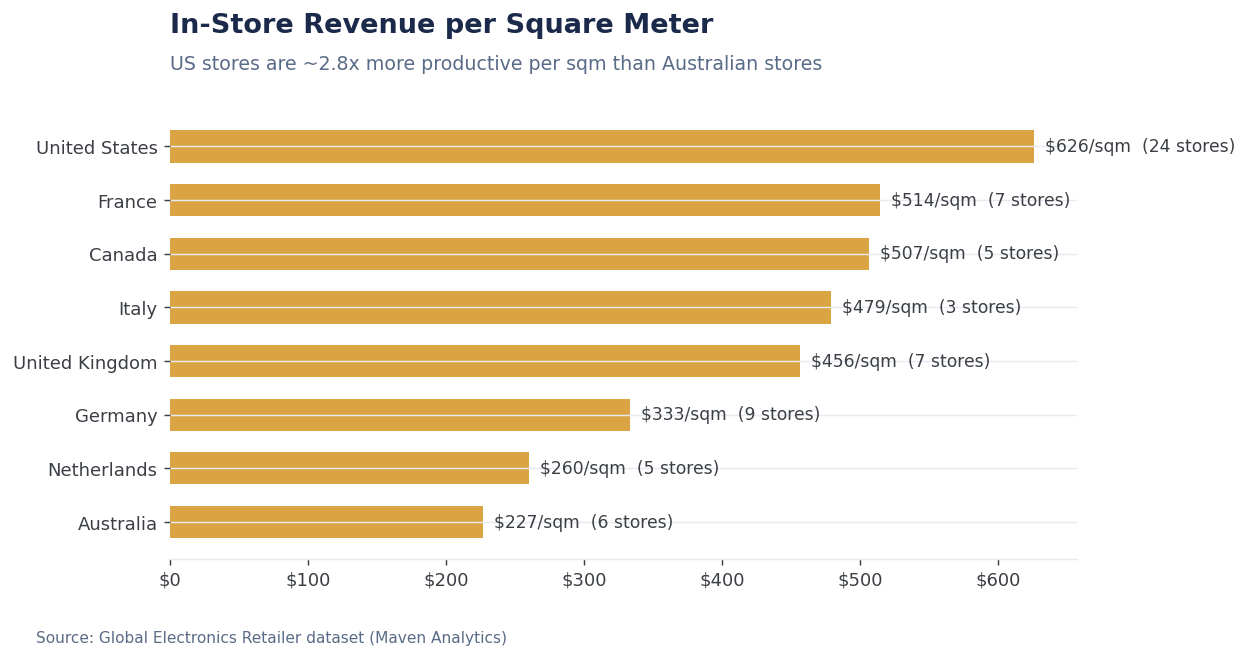

In [4]:
instore = df[df["Store Type"] == "In-Store"]
store_rev = instore.groupby("StoreKey")["Revenue_USD"].sum().reset_index()
store_full = stores.merge(store_rev, on="StoreKey", how="left")
store_full["Revenue_USD"] = store_full["Revenue_USD"].fillna(0)
store_full = store_full[store_full["StoreKey"] != 0]

store_country = instore.groupby("Country_store").agg(Revenue=("Revenue_USD","sum"))
counts = stores[stores.StoreKey != 0].groupby("Country").agg(n_stores=("StoreKey","count"), total_sqm=("Square Meters","sum"))
merged = store_country.join(counts)
merged["Revenue_per_sqm"] = merged["Revenue"] / merged["total_sqm"]
merged = merged.sort_values("Revenue_per_sqm", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(merged.index, merged["Revenue_per_sqm"], color=COLORS["accent"], height=0.6)
ax.xaxis.set_major_formatter(money_formatter(0))
add_titles(ax, "In-Store Revenue per Square Meter", "US stores are ~2.8x more productive per sqm than Australian stores")
for i, (v, n) in enumerate(zip(merged["Revenue_per_sqm"], merged["n_stores"])):
    ax.text(v, i, f"  ${v:,.0f}/sqm  ({n} stores)", va="center", fontsize=9.5, color=COLORS["text"])
add_source_note(fig)
plt.savefig("../reports/figures/g03_revenue_per_sqm.png")
plt.show()

In [5]:
zero_rev = store_full[store_full["Revenue_USD"] == 0][["StoreKey","Country","Square Meters","Open Date"]]
print(f"{len(zero_rev)} of {len(store_full)} stores ({len(zero_rev)/len(store_full)*100:.0f}%) have zero recorded sales:")
zero_rev

9 of 66 stores (14%) have zero recorded sales:


,StoreKey,Country,Square Meters,Open Date
2,3,Australia,"2,000.00",2012-01-07
6,7,Canada,"1,105.00",2007-05-07
10,11,Canada,"1,210.00",2009-06-03
24,25,Germany,"1,610.00",2010-01-01
34,35,Netherlands,"1,225.00",2007-05-07
45,46,United States,"1,015.00",2012-08-08
51,52,United States,"2,000.00",2009-06-03
57,58,United States,"1,330.00",2007-07-08
59,60,United States,"1,260.00",2005-04-04


### 3.4 Online Penetration Varies Meaningfully by Market

Online share ranges from 18% (Italy, UK) to 24% (Australia) — worth investigating for markets with lower in-store store-count/sqm coverage, where online may be substituting for physical presence.

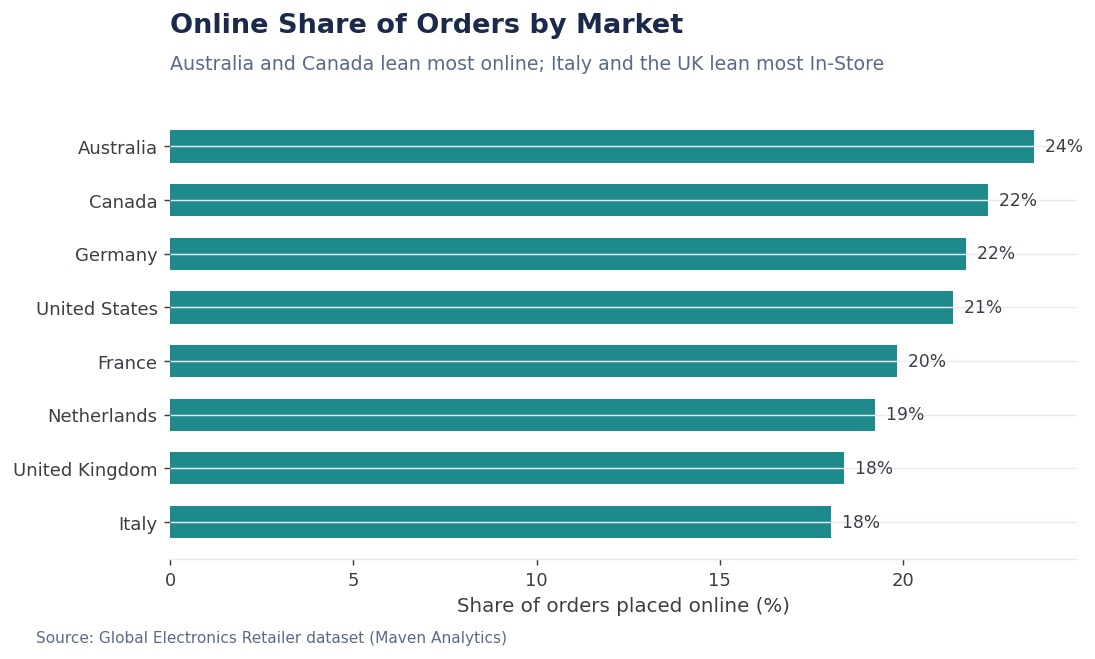

In [6]:
online_share = df.groupby("Country_customer").apply(lambda x: (x["Store Type"]=="Online").mean()).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(online_share.index, online_share.values*100, color=COLORS["positive"], height=0.6)
add_titles(ax, "Online Share of Orders by Market", "Australia and Canada lean most online; Italy and the UK lean most In-Store")
for i, v in enumerate(online_share.values*100):
    ax.text(v, i, f"  {v:.0f}%", va="center", fontsize=9.5, color=COLORS["text"])
ax.set_xlabel("Share of orders placed online (%)")
add_source_note(fig)
plt.savefig("../reports/figures/g04_online_share_by_country.png")
plt.show()

### 3.5 Growth Shape Is Consistent Across Top Markets

The top 4 markets by revenue all show the *same shape* of growth and 2020 pullback — this is a company-wide dynamic (see Module 1), not something specific to any one market.

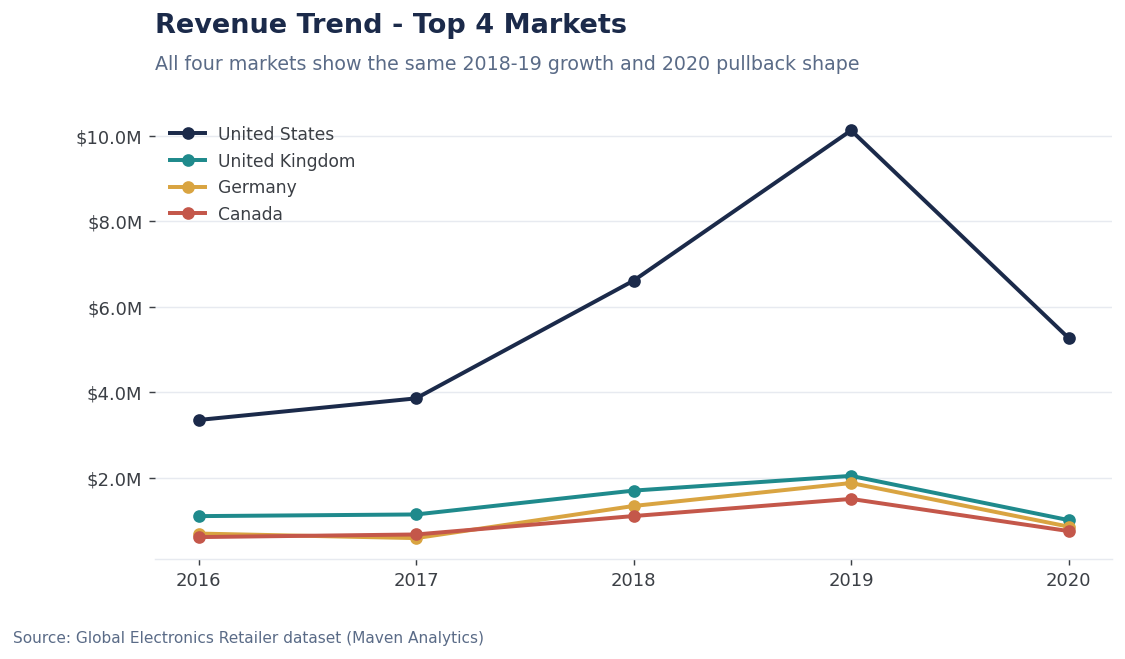

In [7]:
full = df[df["Order_Year"].between(2016, 2020)]
top4 = full.groupby("Country_customer")["Revenue_USD"].sum().sort_values(ascending=False).head(4).index.tolist()
pivot = full[full["Country_customer"].isin(top4)].groupby(["Order_Year","Country_customer"])["Revenue_USD"].sum().unstack()

fig, ax = plt.subplots(figsize=(9.5, 5))
for i, c in enumerate(top4):
    ax.plot(pivot.index.astype(str), pivot[c], marker="o", linewidth=2.2, color=PALETTE[i], label=c)
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Revenue Trend - Top 4 Markets", "All four markets show the same 2018-19 growth and 2020 pullback shape")
ax.legend(loc="upper left", fontsize=9.5)
add_source_note(fig)
plt.savefig("../reports/figures/g05_top_markets_trend.png")
plt.show()

### 3.6 What Actually Drives Store Revenue: Size, Not Age

Store size (sqm) has a moderate positive relationship with revenue (r≈0.60) — bigger stores tend to sell more, but size alone doesn't fully determine performance. Store age shows essentially **no relationship** (r=-0.13): a store opened in 2005 is no more or less likely to perform well than one opened in 2015. This suggests performance is driven by location/demand and merchandising execution, not simply by how established a store is.

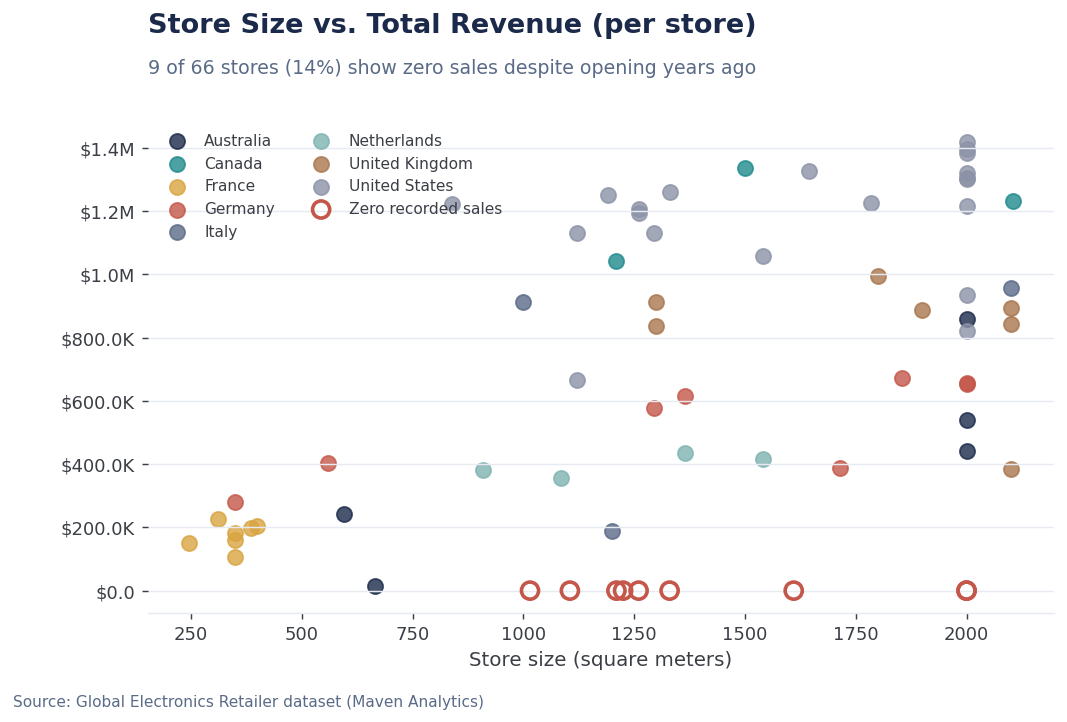

Size-Revenue correlation (active stores): 0.6


In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
active = store_full[store_full["Revenue_USD"] > 0]
zero_rev_pts = store_full[store_full["Revenue_USD"] == 0]
for c, sub in active.groupby("Country"):
    ax.scatter(sub["Square Meters"], sub["Revenue_USD"], s=70, alpha=0.8, color=country_colors[c], label=c)
ax.scatter(zero_rev_pts["Square Meters"], zero_rev_pts["Revenue_USD"], s=90, facecolors="none",
           edgecolors=COLORS["negative"], linewidths=2, label="Zero recorded sales", zorder=5)
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Store Size vs. Total Revenue (per store)",
           f"{len(zero_rev_pts)} of {len(store_full)} stores (14%) show zero sales despite opening years ago")
ax.set_xlabel("Store size (square meters)")
ax.legend(loc="upper left", fontsize=8.5, ncols=2)
add_source_note(fig)
plt.savefig("../reports/figures/g06_store_size_vs_revenue.png")
plt.show()

print("Size-Revenue correlation (active stores):", round(active["Square Meters"].corr(active["Revenue_USD"]), 2))

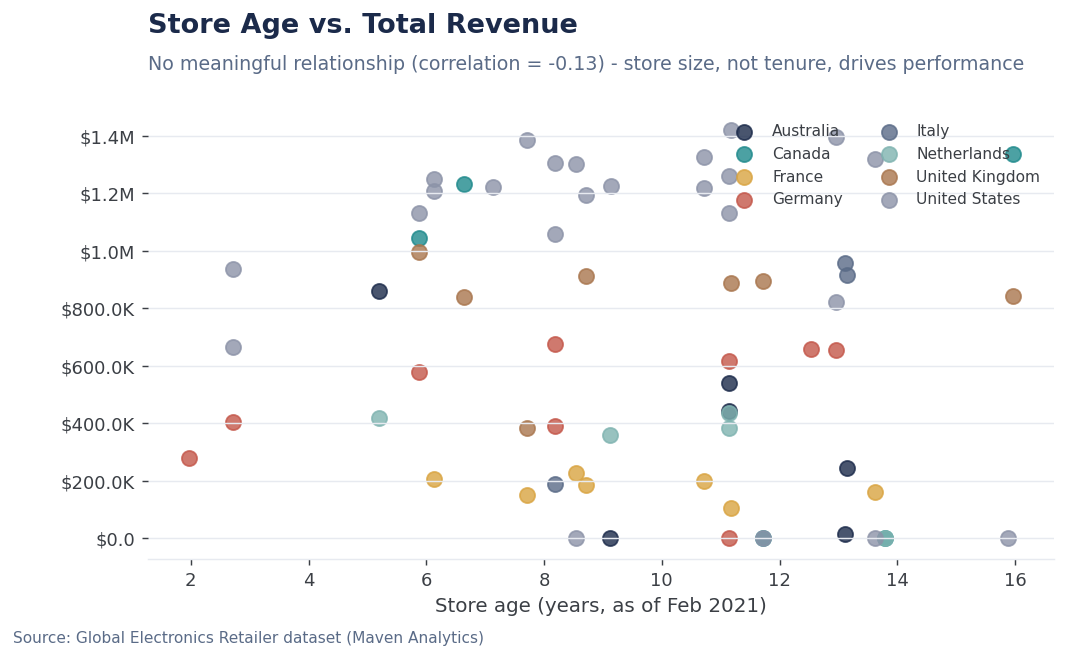

In [9]:
store_full["Age_years"] = (pd.Timestamp("2021-02-20") - store_full["Open Date"]).dt.days / 365.25

fig, ax = plt.subplots(figsize=(9, 5))
for c, sub in store_full.groupby("Country"):
    ax.scatter(sub["Age_years"], sub["Revenue_USD"], s=70, alpha=0.8, color=country_colors[c], label=c)
ax.yaxis.set_major_formatter(money_formatter())
corr = store_full["Age_years"].corr(store_full["Revenue_USD"])
add_titles(ax, "Store Age vs. Total Revenue", f"No meaningful relationship (correlation = {corr:.2f}) - store size, not tenure, drives performance")
ax.set_xlabel("Store age (years, as of Feb 2021)")
ax.legend(loc="upper right", fontsize=8.5, ncols=2)
add_source_note(fig)
plt.savefig("../reports/figures/g09_store_age_vs_revenue.png")
plt.show()

### 3.7 Customer Value and Continent Rollup

US customers are worth ~50% more over the dataset's history than French or Australian customers ($5,235 vs ~$3,460-3,470) — consistent with the US also having the most productive stores. At the continent level, North America contributes 62% of revenue, Europe 33%, and Australia 5%, with margin flat across all three.

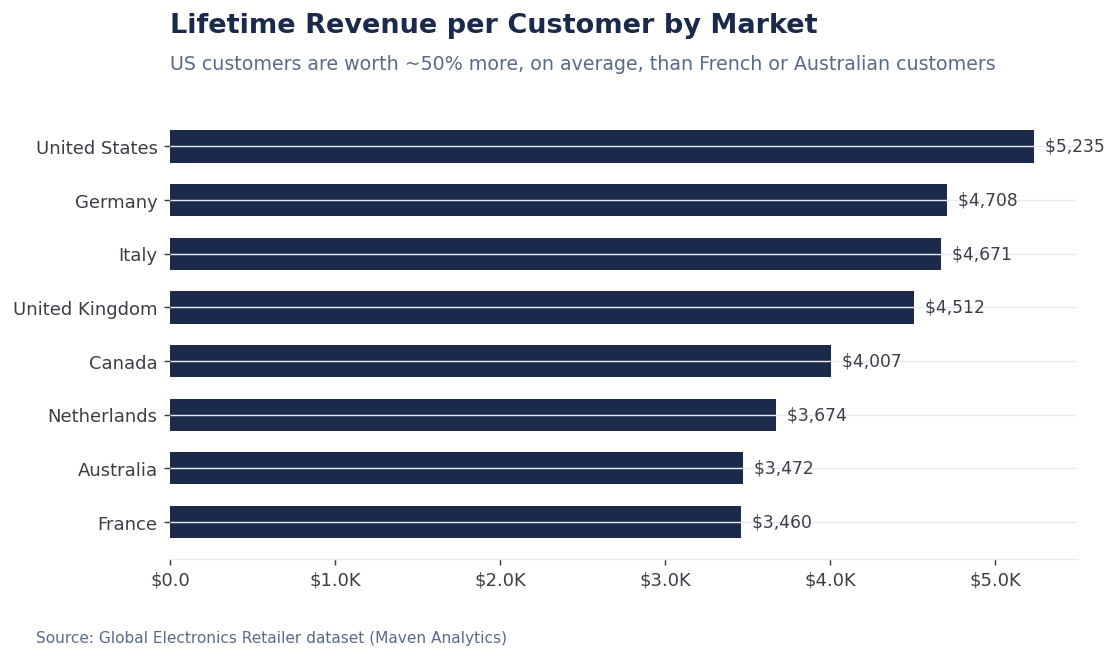

In [10]:
rpc = df.groupby("Country_customer").agg(Revenue=("Revenue_USD","sum"), Customers=("CustomerKey","nunique"))
rpc["Rev_per_customer"] = rpc["Revenue"] / rpc["Customers"]
rpc = rpc.sort_values("Rev_per_customer", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(rpc.index, rpc["Rev_per_customer"], color=COLORS["primary"], height=0.6)
ax.xaxis.set_major_formatter(money_formatter())
add_titles(ax, "Lifetime Revenue per Customer by Market", "US customers are worth ~50% more, on average, than French or Australian customers")
for i, v in enumerate(rpc["Rev_per_customer"]):
    ax.text(v, i, f"  ${v:,.0f}", va="center", fontsize=9.5, color=COLORS["text"])
add_source_note(fig)
plt.savefig("../reports/figures/g07_revenue_per_customer.png")
plt.show()

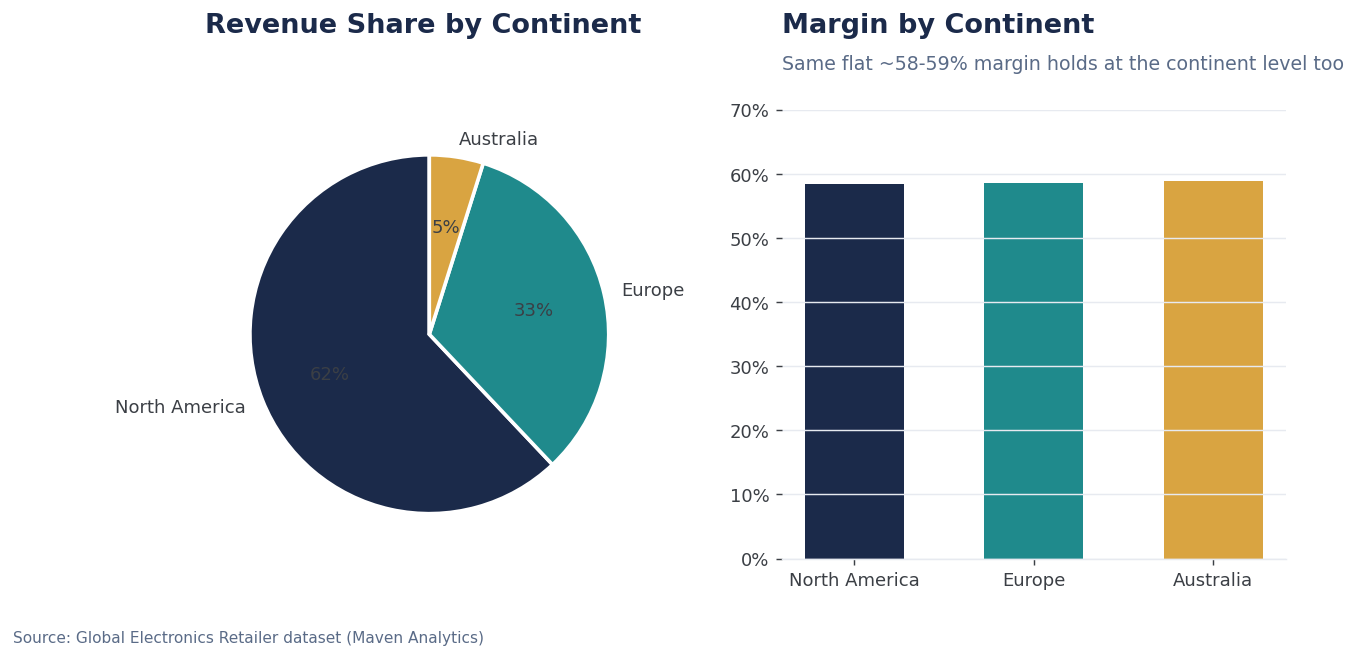

In [11]:
cont = df.groupby("Continent").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum")).sort_values("Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].pie(cont["Revenue"], labels=cont.index, autopct="%1.0f%%", colors=PALETTE[:len(cont)],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
add_titles(axes[0], "Revenue Share by Continent", "")

axes[1].bar(cont.index, cont["Profit"] / cont["Revenue"], color=PALETTE[:len(cont)], width=0.55)
axes[1].yaxis.set_major_formatter(pct_formatter(0))
axes[1].set_ylim(0, 0.7)
add_titles(axes[1], "Margin by Continent", "Same flat ~58-59% margin holds at the continent level too")
add_source_note(fig)
plt.savefig("../reports/figures/g08_continent_split.png")
plt.show()

## 4. Business Conclusions & Recommendations

1. **Don't just chase revenue rankings — chase productivity.** The US isn't just the biggest market, it's also the most efficient store footprint (highest $/sqm). Before opening new stores elsewhere, benchmark planned store sizes and locations against what makes US stores so productive.

2. **Investigate the 9 zero-revenue stores immediately.** Whether they're closed, mis-joined in the data warehouse, or genuinely dormant assets, this is a concrete, actionable finding for store operations and data engineering teams alike.

3. **Margin is not a lever available at the geography level.** Since margin is flat everywhere (~58-59%), any market-specific profitability initiative needs to target volume, cost-to-serve, or product mix — not local pricing.

4. **Store age doesn't predict performance — so don't be afraid of new locations, and don't assume old stores are safe.** Every new-store decision should be evaluated on the same size/location criteria as the best performers, not on the assumption that "established" stores are automatically stronger.

5. **Online penetration gaps (e.g., Italy and the UK at ~18%) represent a growth lever** that doesn't require any new store capex — worth a targeted digital-marketing push in markets currently under-indexed online relative to Australia/Canada.
